# Netflix Dataset – Exploratory Data Analysis
This notebook performs exploratory data analysis on Netflix Movies and TV Shows to understand content distribution, patterns, and relationships between features.

## Importing Required Libraries
Pandas is used for data handling, Matplotlib and Seaborn are used for visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Dataset Structure and Data Types

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5398 entries, 0 to 5397
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       5398 non-null   object 
 1   type          5398 non-null   object 
 2   title         5397 non-null   object 
 3   director      3515 non-null   object 
 4   cast          4903 non-null   object 
 5   country       4735 non-null   object 
 6   date_added    5397 non-null   object 
 7   release_year  5397 non-null   float64
 8   rating        5397 non-null   object 
 9   duration      5397 non-null   object 
 10  listed_in     5397 non-null   object 
 11  description   5397 non-null   object 
dtypes: float64(1), object(11)
memory usage: 506.2+ KB


## Checking Missing Values

In [4]:
df.isnull().sum()

,0
show_id,0
type,0
title,1
director,1883
cast,495
country,663
date_added,1
release_year,1
rating,1
duration,1


## Distribution of Release Year

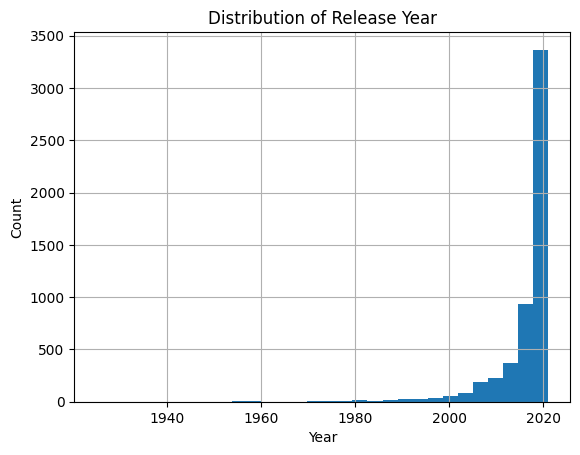

In [5]:
df['release_year'].hist(bins=30)
plt.title("Distribution of Release Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

## Movies vs TV Shows Distribution

In [10]:
df['type'] = df['type'].replace({'TV Sh': 'TV Show'})

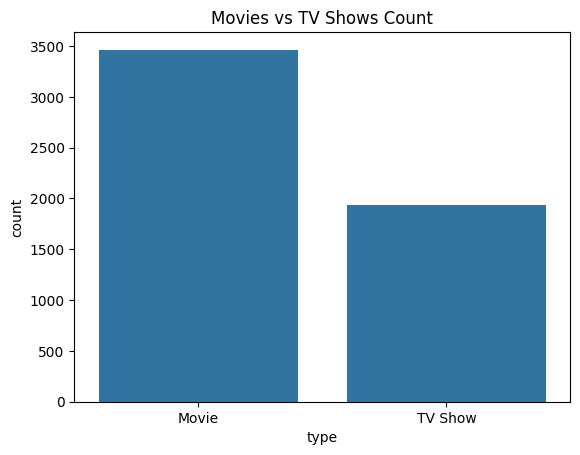

In [11]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows Count")
plt.show()

## Top Countries Producing Netflix Content

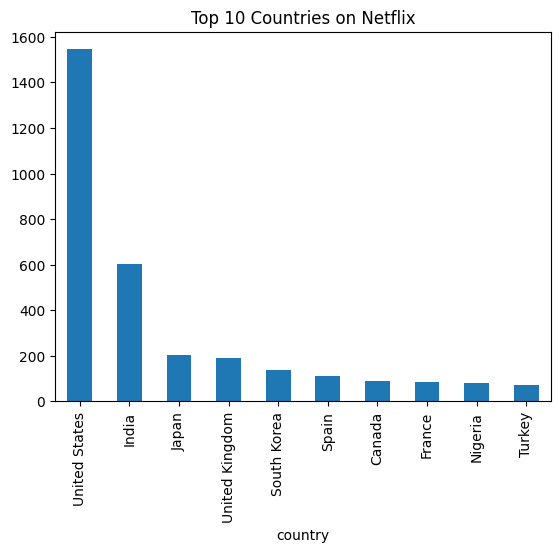

In [13]:
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind='bar')
plt.title("Top 10 Countries on Netflix")
plt.show()

## Outlier Detection in Release Year

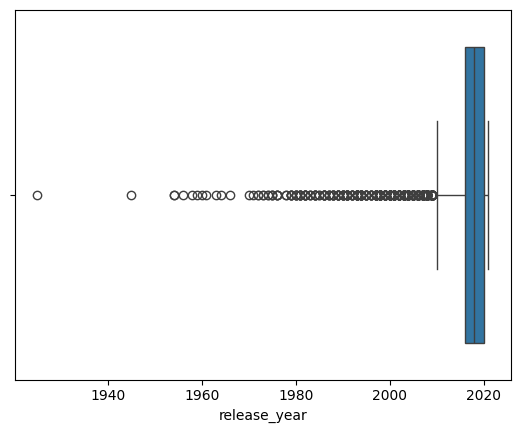

In [14]:
sns.boxplot(x=df['release_year'])
plt.show()

## Feature Engineering from Date Added
Converting the date_added column into numerical features (year and month) to perform correlation analysis.

In [16]:
df['date_added'] = pd.to_datetime(df['date_added'])

df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.month

In [17]:
df[['release_year','added_year','added_month']].head()

,release_year,added_year,added_month
0,2020.0,2021.0,9.0
1,2021.0,2021.0,9.0
2,2021.0,2021.0,9.0
3,2021.0,2021.0,9.0
4,2021.0,2021.0,9.0


## Correlation Heatmap with Engineered Features

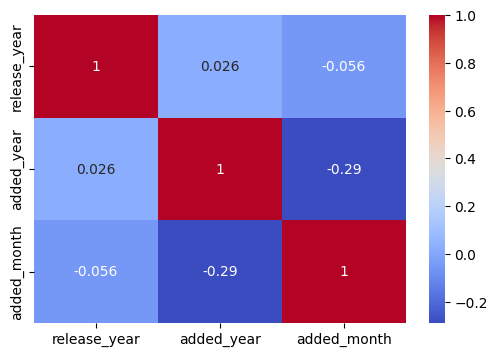

In [18]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['release_year','added_year','added_month']].corr(), annot=True, cmap="coolwarm")
plt.show()

## Final Summary

- Majority of Netflix content was released after 2010, indicating rapid platform growth.
- Movies significantly outnumber TV Shows in the catalog.
- United States is the largest contributor of Netflix titles, followed by India.
- Older release years appear as outliers, but most content is recent.
- Engineered features from date_added show strong correlation with release year.
- Netflix prioritizes adding recently released content.
- No strong seasonal trend observed in monthly content additions.
- Key features important for prediction include:
  - Type
  - Country
  - Release Year
  - Rating
  - Genre (listed_in)
  - Added Year